## PBL-I: Regression



1. Import libraries


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    LinearRegression,
    HuberRegressor,
    Ridge,
    BayesianRidge
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

2. Load the datasets

In [2]:
import pandas as pd

train = pd.read_csv("/content/train_final.csv")
val = pd.read_csv("/content/validation_final.csv")
test = pd.read_csv("/content/test_final.csv")

features = pd.read_csv("/content/feature_columns.csv").iloc[:, 0].tolist()
target = "dst"

X_train = train[features]
y_train = train[target]
X_val = val[features]
y_val = val[target]
X_test = test[features]
y_test = test[target]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (19349, 39)
Validation: (4141, 39)
Test: (4142, 39)


3. Preprocess the data

We'll impute missing values and standardize features. Both transformations are fitted on the training set only to avoid data leakage

In [3]:
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train = imputer.fit_transform(X_train)
X_val = imputer.transform(X_val)
X_test = imputer.transform(X_test)

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Preprocessing complete!")

Preprocessing complete!


4. Implement Maximum Likelihood Estimation

For linear regression with Gaussian errors, maximizing the likelihood gives the same coefficients as minimizing the sum of squared errors.

What this implements:

Estimates the regression coefficients by maximizing the Gaussian likelihood.

Estimates the Gaussian error variance.

Uses the estimated coefficients to make predictions.

In [4]:
def mle_regression(X, y, X_new):
    # Add intercept
    X_bias = np.column_stack([
        np.ones(X.shape[0]), X
    ])

    X_new_bias = np.column_stack([
        np.ones(X_new.shape[0]), X_new
    ])

    # MLE coefficient estimates
    coefficients = np.linalg.lstsq(
        X_bias, y, rcond=None
    )[0]

    # Gaussian noise variance MLE
    residuals = y - X_bias @ coefficients
    variance = np.mean(residuals ** 2)

    predictions = X_new_bias @ coefficients

    return predictions, coefficients, variance


mle_val_pred, mle_coefficients, mle_variance = (
    mle_regression(X_train, y_train, X_val)
)

print("MLE completed")
print("Estimated noise variance:", mle_variance)

MLE completed
Estimated noise variance: 272.27049225939953


5. Implement Least Squares Regression

This is ordinary linear regression. It minimizes the sum of squared residuals.

In [5]:
least_squares = LinearRegression()

least_squares.fit(X_train, y_train)

ls_val_pred = least_squares.predict(X_val)

print("Least Squares completed")

Least Squares completed


6. Implement Robust Linear Regression

We'll use Huber Regression, which is the robust regression method illustrated in your PPT. It reduces the influence of large residuals.The epsilon parameter controls the transition between the quadratic and linear portions of the Huber loss.

In [6]:
robust = HuberRegressor(
    epsilon=1.35,
    max_iter=1000
)

robust.fit(X_train, y_train)

robust_val_pred = robust.predict(X_val)

print("Robust Regression completed")

Robust Regression completed


7. Implement Ridge Regression

Ridge regression adds an L2 penalty to the squared error. We'll use a validation set to choose the regularization strength, λ.

In [7]:
ridge_models = {}

for alpha in [0.01, 0.1, 1, 10, 100]:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    ridge_models[alpha] = model

print("Ridge Regression completed")

Ridge Regression completed


8. Implement Bayesian Linear Regression

We'll use BayesianRidge, which estimates a posterior distribution over regression coefficients, with hyperparameters estimated from the training data. Unlike ordinary linear regression, Bayesian regression provides uncertainty information about its coefficient estimates.

In [8]:
bayesian = BayesianRidge()

bayesian.fit(X_train, y_train)

bayesian_val_pred = bayesian.predict(X_val)

print("Bayesian Linear Regression completed")

Bayesian Linear Regression completed


9. Compare all regression models on validation data

This is where we evaluate the five approaches using MAE, RMSE and R^2

In [9]:
def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(
            mean_squared_error(y_true, y_pred)
        ),
        "R2": r2_score(y_true, y_pred)
    }


validation_predictions = {
    "MLE": mle_val_pred,
    "Least Squares": ls_val_pred,
    "Robust Regression": robust_val_pred,
    "Bayesian Regression": bayesian_val_pred
}

for alpha, model in ridge_models.items():
    validation_predictions[f"Ridge (alpha={alpha})"] = (
        model.predict(X_val)
    )

validation_results = []

for name, predictions in validation_predictions.items():
    metrics = evaluate(y_val, predictions)
    metrics["Model"] = name
    validation_results.append(metrics)

validation_results = pd.DataFrame(validation_results)

validation_results = validation_results[
    ["Model", "MAE", "RMSE", "R2"]
].sort_values("RMSE")

print(validation_results.to_string(index=False))

              Model       MAE      RMSE       R2
                MLE 15.457204 22.706283 0.480174
      Least Squares 15.457204 22.706283 0.480174
  Ridge (alpha=100) 15.563789 22.794376 0.476133
Bayesian Regression 15.589996 22.860639 0.473083
   Ridge (alpha=10) 15.593063 22.869861 0.472658
 Ridge (alpha=0.01) 15.593095 22.877971 0.472284
    Ridge (alpha=1) 15.596934 22.881896 0.472102
  Ridge (alpha=0.1) 15.596948 22.882698 0.472065
  Robust Regression 15.682260 23.517708 0.442358


10. Select the model and evaluate on the test set

We'll select the model using validation RMSE, then refit the selected model using the combined training and validation data. The test set remains unseen until final evaluation.

In [10]:
best_name = validation_results.iloc[0]["Model"]
print("Selected model:", best_name)

X_train_val = np.vstack([X_train, X_val])
y_train_val = np.concatenate([y_train, y_val])

if best_name == "MLE":
    test_pred, _, _ = mle_regression(
        X_train_val, y_train_val, X_test
    )

elif best_name == "Least Squares":
    final_model = LinearRegression()

elif best_name == "Robust Regression":
    final_model = HuberRegressor(
        epsilon=1.35, max_iter=1000
    )

elif best_name == "Bayesian Regression":
    final_model = BayesianRidge()

elif best_name.startswith("Ridge"):
    alpha = float(best_name.split("=")[1].rstrip(")"))
    final_model = Ridge(alpha=alpha)

if best_name != "MLE":
    final_model.fit(X_train_val, y_train_val)
    test_pred = final_model.predict(X_test)

test_metrics = evaluate(y_test, test_pred)

print("\nFinal test results")
for metric, value in test_metrics.items():
    print(f"{metric}: {value:.4f}")

Selected model: MLE

Final test results
MAE: 13.4293
RMSE: 21.1548
R2: 0.5527


11. Plot actual versus predicted Dst

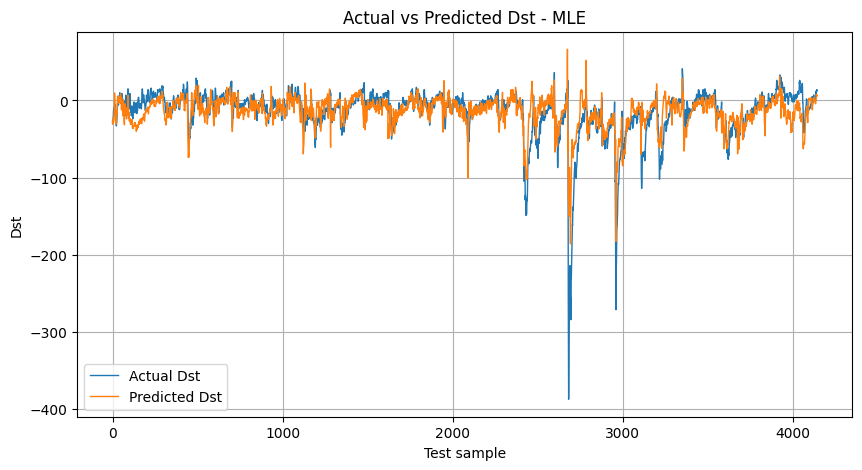

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(
    np.asarray(y_test),
    label="Actual Dst",
    linewidth=1
)

plt.plot(
    test_pred,
    label="Predicted Dst",
    linewidth=1
)

plt.title(f"Actual vs Predicted Dst - {best_name}")
plt.xlabel("Test sample")
plt.ylabel("Dst")
plt.legend()
plt.grid(True)
plt.show()


12. Results

Save your validation comparison, test predictions and final metrics so that your teammates can use them for the comparative analysis and presentation.



In [12]:
os.makedirs("results/regression", exist_ok=True)

validation_results.to_csv(
    "results/regression/validation_comparison.csv",
    index=False
)

predictions = pd.DataFrame({
    "actual_dst": y_test,
    "predicted_dst": test_pred
})

predictions.to_csv(
    "results/regression/test_predictions.csv",
    index=False
)

pd.DataFrame([{
    "selected_model": best_name,
    **test_metrics
}]).to_csv(
    "results/regression/final_metrics.csv",
    index=False
)

print("All regression results saved!")

All regression results saved!
